In [16]:
%matplotlib widget
%matplotlib widget
import os
from pathlib import Path
import time
import torch
import numpy as np
import math
import gc
from functools import partial
from dataset_alt import Dataset, load_dataframes_from_folder, reverse_normalization
from torch.utils.data import DataLoader
from transformer_zerostep import GPTConfig, GPT, warmup_cosine_lr
import argparse
import warnings
import matplotlib.pyplot as plt


# set figure parameters
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['axes.labelsize']=14
plt.rcParams['xtick.labelsize']=11
plt.rcParams['ytick.labelsize']=11
plt.rcParams['axes.grid']=True
plt.rcParams['axes.xmargin']=0

In [17]:
# Overall settings
out_dir = "out"

model_name = "new_delay_h10_10k.pt"
# model_name = "model_high_speed.pt"

current_path = os.getcwd().split("in-context-bldc")[0]
data_path = os.path.join(current_path,"in-context-bldc", "data")

folder = "simulated/50_percent_control/validation"
# folder = "CL_experiments_double_sensor_control/test/inertia13"
folder_path = os.path.join(data_path, folder)

# Compute settings
cuda_device = "cuda:0"
no_cuda = True
threads = 10
compile = False

# Configure compute
torch.set_num_threads(threads) 
use_cuda = not no_cuda and torch.cuda.is_available()
device_name  = cuda_device if use_cuda else "cpu"
device = torch.device(device_name)
device_type = 'cuda' if 'cuda' in device_name else 'cpu' # for later use in torch.autocast
torch.set_float32_matmul_precision("high")
print(torch.cuda.is_available())
# Create out dir
out_dir = Path(out_dir)
exp_data = torch.load(out_dir/model_name, map_location=device, weights_only=False)
seq_len = exp_data["cfg"].seq_len
nx = exp_data["cfg"].nx
exp_data["iter_num"]
print(seq_len)
print(exp_data["iter_num"])
print(exp_data['best_val_loss'])
print(exp_data["cfg"])
print(exp_data["cfg"].lr)
print(exp_data["train_time"]/3600)


True
10
9888
0.0005529707050300203
Namespace(model_dir='out', out_file='new_delay_h10', in_file='new_delay_h10', init_from='scratch', seed=42, log_wandb=False, nx=4, nu=8, ny=1, seq_len=10, mag_range=(0.5, 0.97), phase_range=(0.0, 1.5707963267948966), fixed_system=False, n_layer=8, n_head=4, n_embd=16, dropout=0, bias=False, batch_size=128, max_iters=30000, warmup_iters=5000, lr=1e-05, weight_decay=0.0, eval_interval=10, eval_iters=10, fixed_lr=False, threads=16, no_cuda=False, cuda_device='cuda:0', compile=False, beta1=0.9, beta2=0.95, block_size=10, lr_decay_iters=30000, min_lr=1.0000000000000002e-06, decay_lr=True, eval_batch_size=128)
1e-05
3.96572324819035


In [18]:
exp_data.keys()

dict_keys(['model', 'optimizer', 'model_args', 'iter_num', 'train_time', 'LOSS', 'LOSS_VAL', 'best_val_loss', 'cfg'])

number of parameters: 0.03M


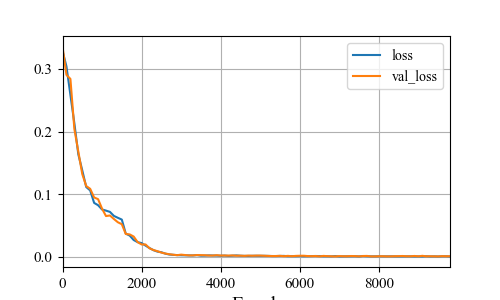

Model size in KB: 98.31640625


In [19]:
# generate the model
model_args = exp_data["model_args"]
gptconf = GPTConfig(**model_args)
model = GPT(gptconf).to(device)
# print(model.get_num_params())

state_dict = exp_data["model"]
unwanted_prefix = '_orig_mod.'
for k,v in list(state_dict.items()):
    if k.startswith(unwanted_prefix):
        state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)
    if k.startswith('module.'):
        state_dict[k[7:]] = v
        state_dict.pop(k)

model.load_state_dict(state_dict)

#plot loss profile
plt.figure(figsize=(5,3))
plt.plot(np.arange(exp_data['iter_num'])[::100], exp_data['LOSS'][::100], label="loss")
plt.plot(np.arange(exp_data['iter_num'])[::100], exp_data['LOSS_VAL'][::100], label="val_loss")
plt.xlabel("Epoch")
plt.legend()
plt.show()

# compute model size
size_in_bytes = sum(param.numel() * param.element_size() for param in model.parameters())
size_in_bytes += sum(buffer.numel() * buffer.element_size() for buffer in model.buffers())

# Convert bytes to kilobytes
size_in_kb = size_in_bytes / 1024
print('Model size in KB:', size_in_kb)

In [20]:
# import copy
# model_name_to_save = "test_controller.pt"
# model_name_to_save2 = "test_controller2.pt"
# torch.save(model, model_name_to_save)

# example_input = torch.randn(1, 10, 8)  # Example for an image input

# model_copy = copy.deepcopy(model)
# model_copy.to('cpu')
# model_copy(example_input)

# # torch.jit.save(model, model_name_to_save2)

In [21]:
# from torchsummary import summary
# model = torch.load(model_name_to_save, weights_only=False)
# summary(model, (seq_len, 8))

30000


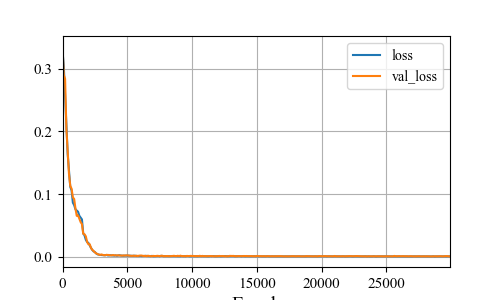

In [22]:
# plot the full training loss profile, if the model reached the final iteration during training
try:
    model_name_check = model_name[:-6] + "loss_check.pt"
    exp_data_check = torch.load(out_dir/model_name_check, map_location=device, weights_only=False)
    # print(model_name_check)
    print(exp_data_check["iter_num"])
    
    plt.figure(figsize=(5,3))
    plt.plot(np.arange(exp_data_check['iter_num'])[::100], exp_data_check['LOSS'][::100], label="loss")
    plt.plot(np.arange(exp_data_check['iter_num'])[::100], exp_data_check['LOSS_VAL'][::100], label="val_loss")
    plt.xlabel("Epoch")
    plt.legend()
    plt.show()
    
except Exception as e:
    print(e)

In [23]:
# assemble the data


dfs = load_dataframes_from_folder(folder_path)
# Log the number of DataFrames loaded
print(f"Loaded {len(dfs)} DataFrames from {folder_path}.") 
H = exp_data["cfg"].seq_len # context window length
# Create an instance of the dataset
dataset_exp = Dataset(dfs=dfs, seq_len=H)
dataloader = DataLoader(dataset_exp, batch_size=exp_data["cfg"].batch_size, shuffle=True)


Loaded 300 DataFrames from c:\Users\39340\Documents\GitHub\in-context-bldc\data\simulated/50_percent_control/validation.


In [24]:
## test each experiment
df_len = len(dfs)
rmse = np.zeros(df_len)
u_full_all = []
y_full_all = []

# extract and stack all the experiments profiles
for i in range(df_len):
    u_full, y_full = dataset_exp.get_full_experiment(i)
    u_full, y_full = u_full.to(device), y_full.to(device)

    u_full_all.append(u_full)
    y_full_all.append(y_full)

u_full_all = torch.stack(u_full_all, dim=0)
y_full_all = torch.stack(y_full_all, dim=0)
y_pred_all = torch.zeros_like(y_full_all)



with torch.no_grad():
    
    # j index moves along the experiments time instants
    for j in range(y_full_all.shape[1]):
        
        # at time instant j
        # if the number of available samples < the context window, the model is fed only those samples
        if j < H:
            input_val = u_full_all[:, :j+1, :] # first j samples of the experiment

            pred = model(input_val)[:,-1,:] #we consider only the last value of the model estimation
        else:
            input_val = u_full_all[:,j-H+1:j+1, :]

            pred = model(input_val)[:,-1,:] #we consider only the last value of the model estimation
        
        
        y_pred_all[:,j,0] = pred[:,0] # the list of estimations is updated
        
    # input output and predictions are converted back to their original range of values
    u_full_all, y_full_all, y_pred_all  = reverse_normalization(u_full_all, y_full_all, y_pred_all)


In [25]:

# compute the rmse for each experiment, and produce its average
for i in range(df_len):
    y_tmp = y_full_all[i,:,:].cpu().numpy()
    y_pred_tmp = y_pred_all[i,:,:].cpu().numpy()
    rmse[i] = np.sqrt(((y_tmp-y_pred_tmp)**2).mean())

print("Average rmse: ", rmse.mean())


Average rmse:  0.15299655812482038


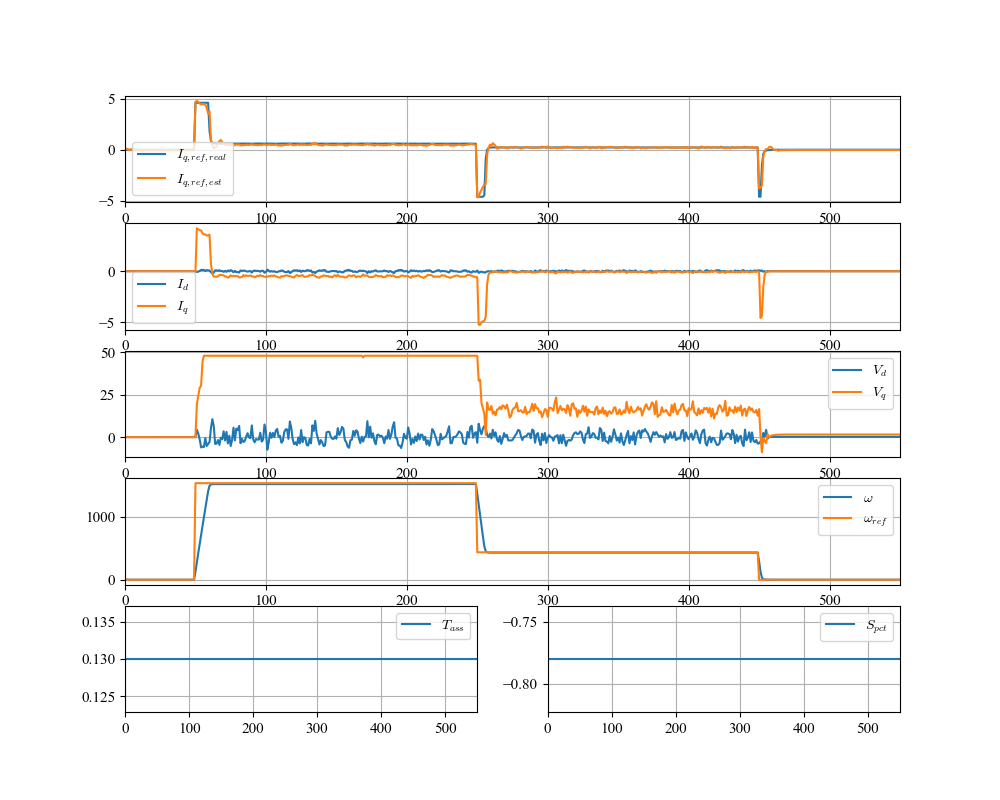

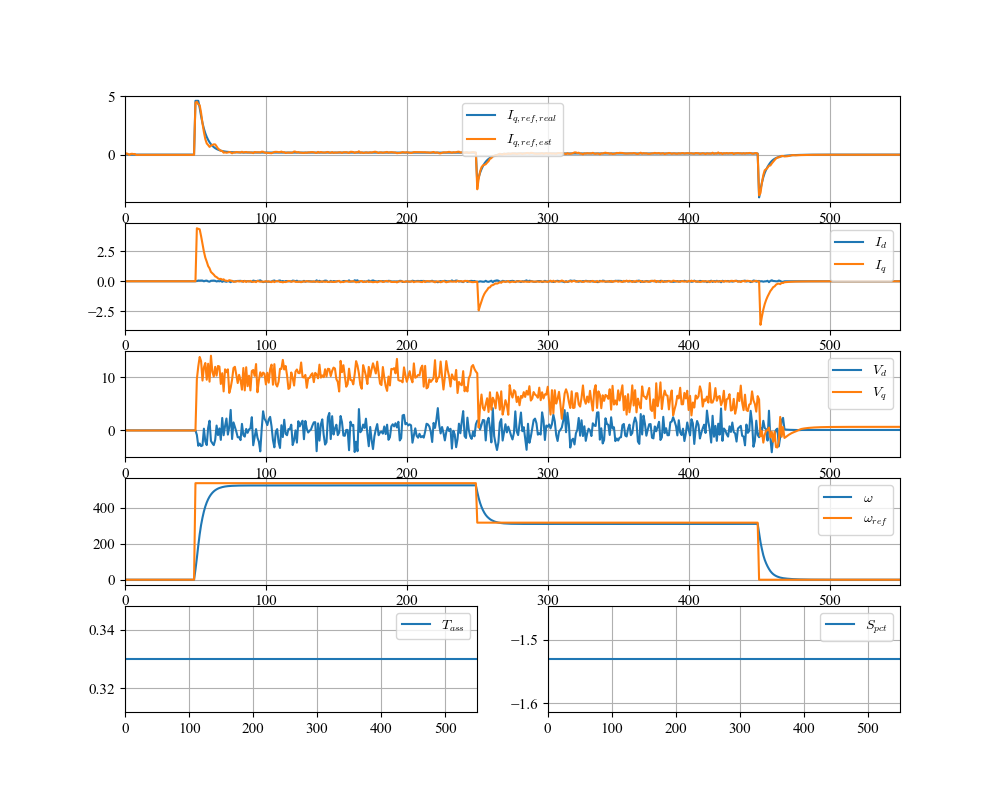

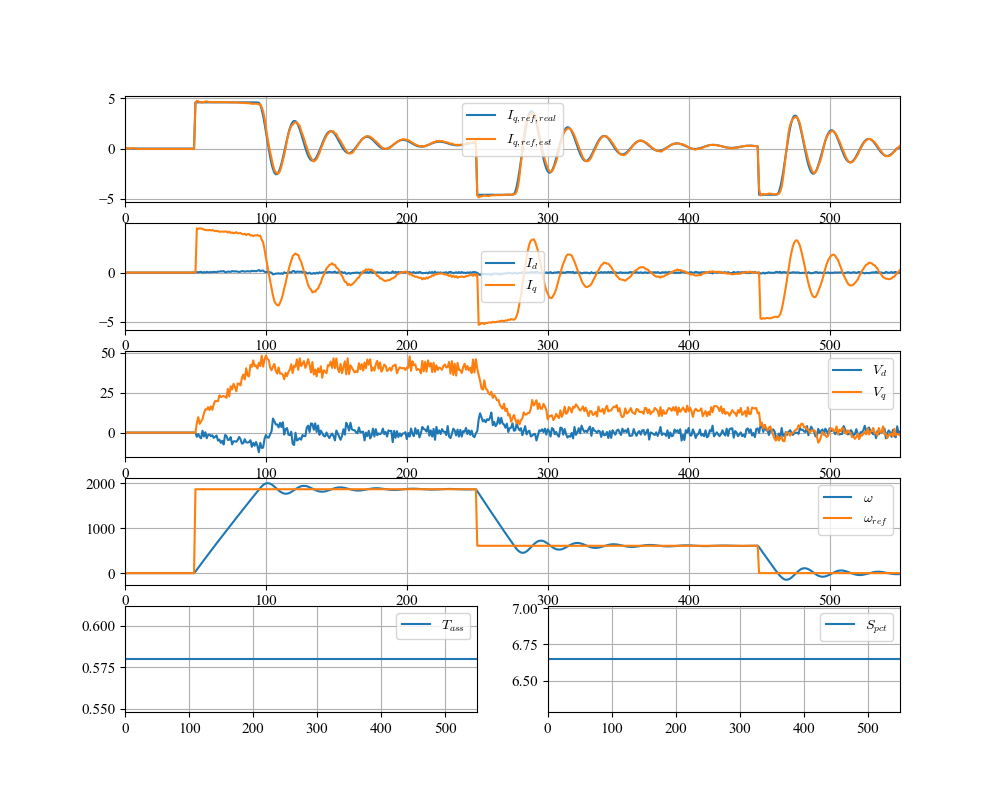

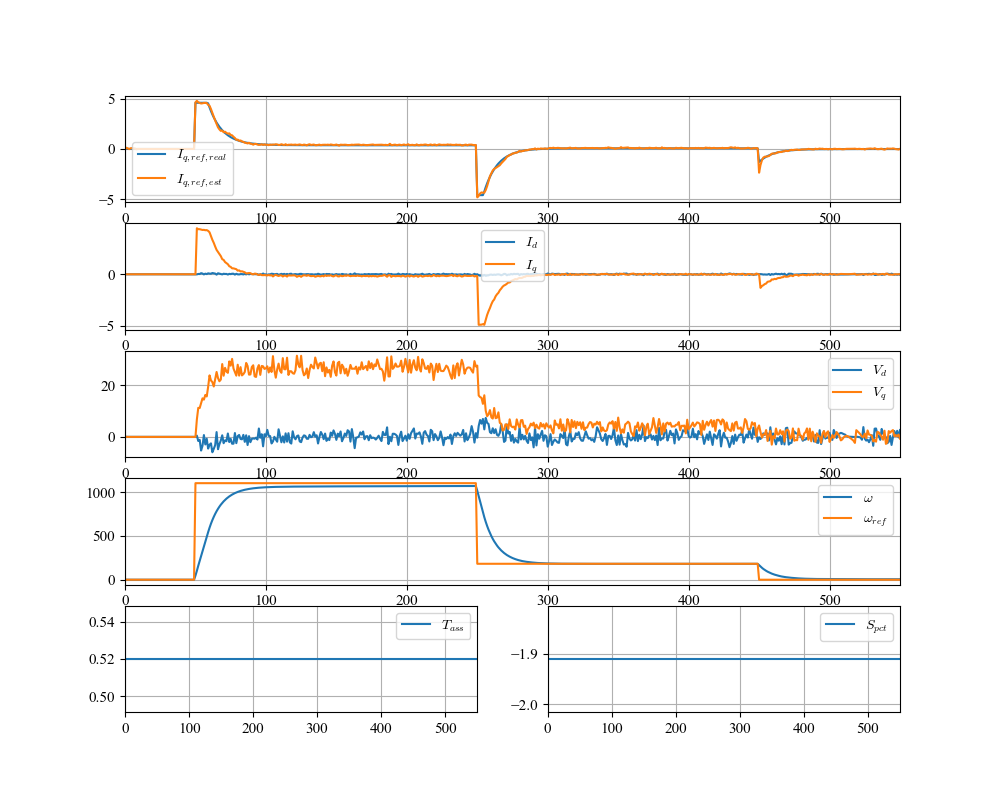

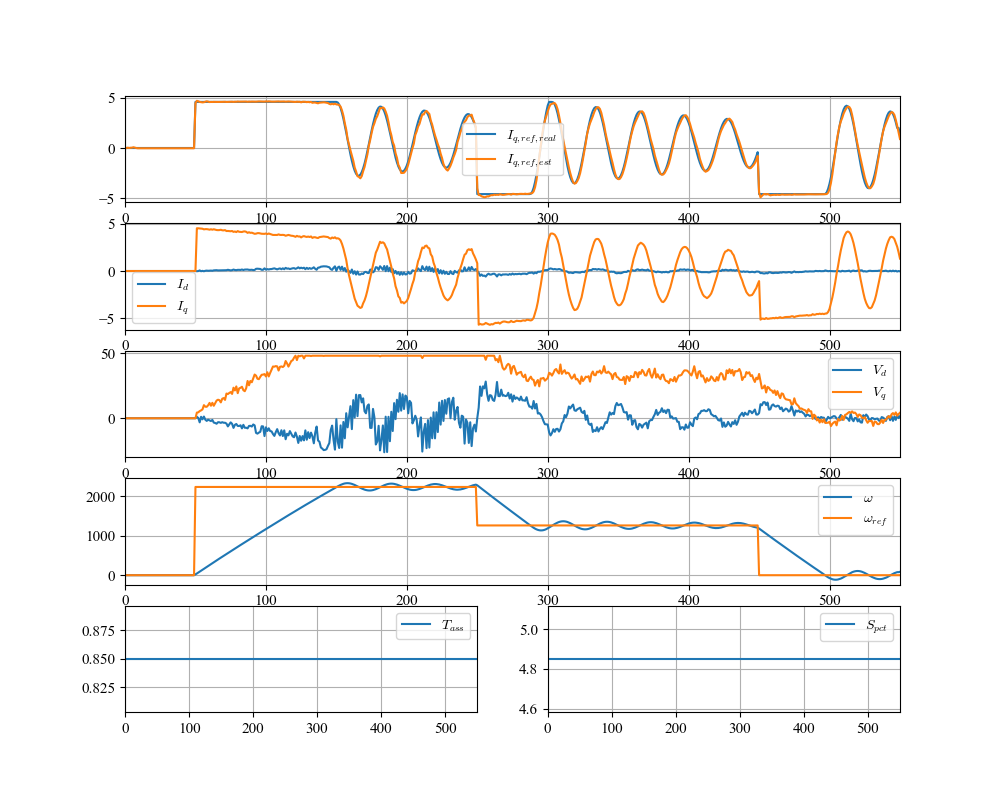

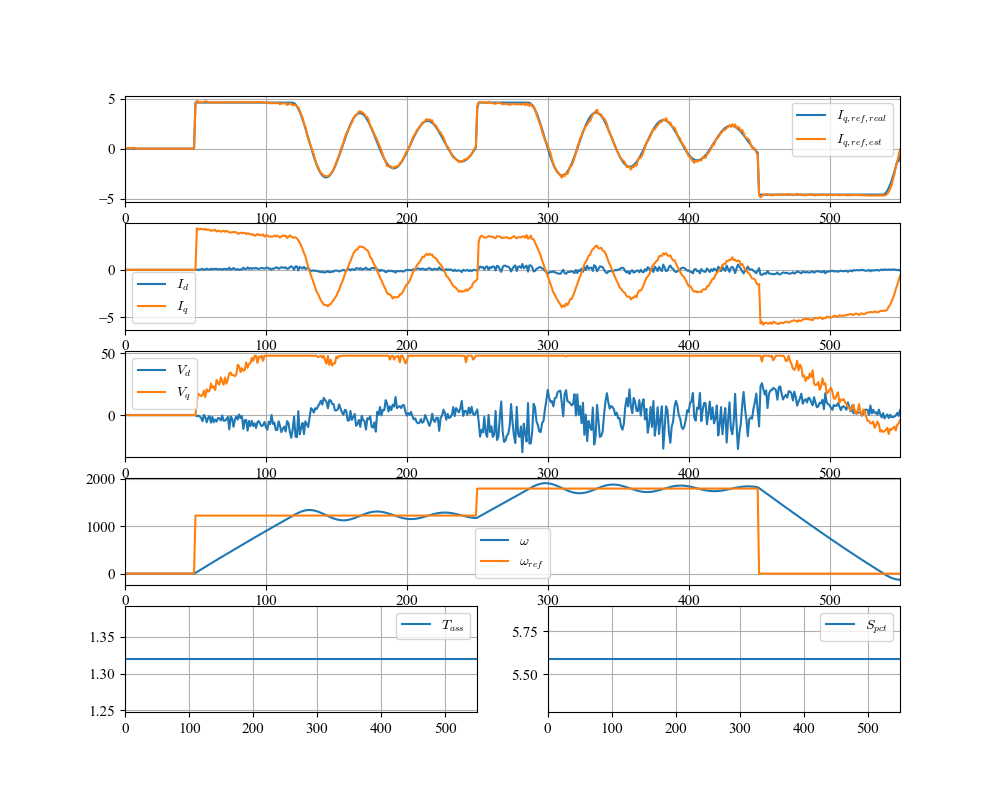

C:\Users\39340\AppData\Local\Temp\ipykernel_27732\1278296944.py:10: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(10,8))


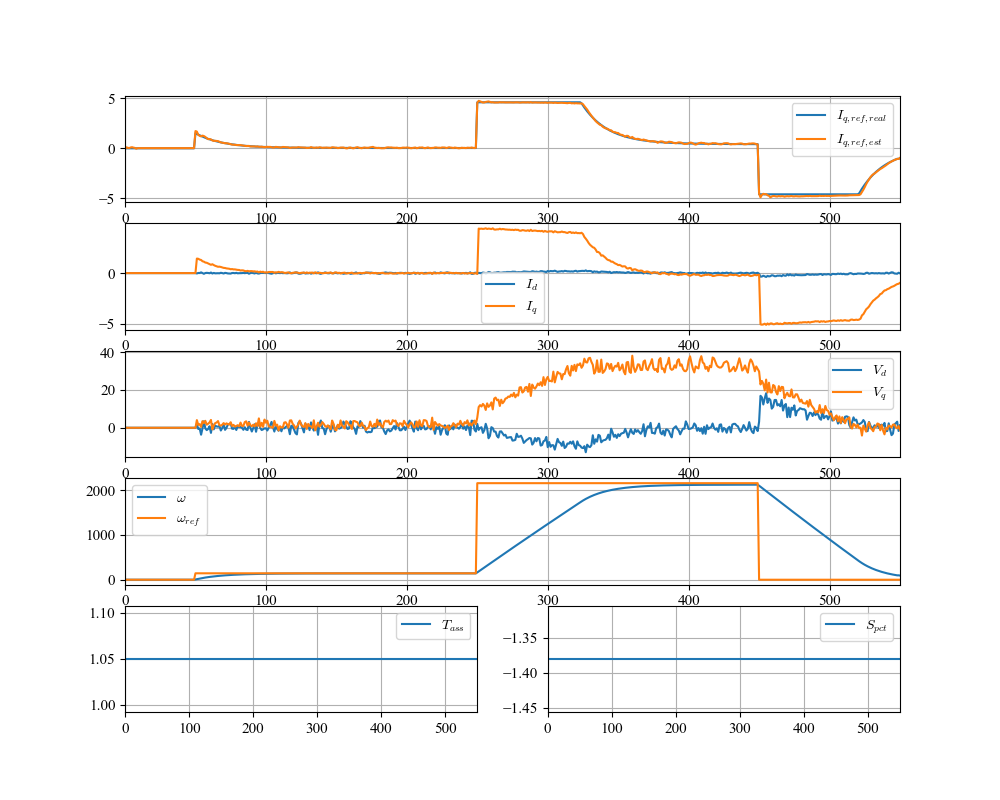

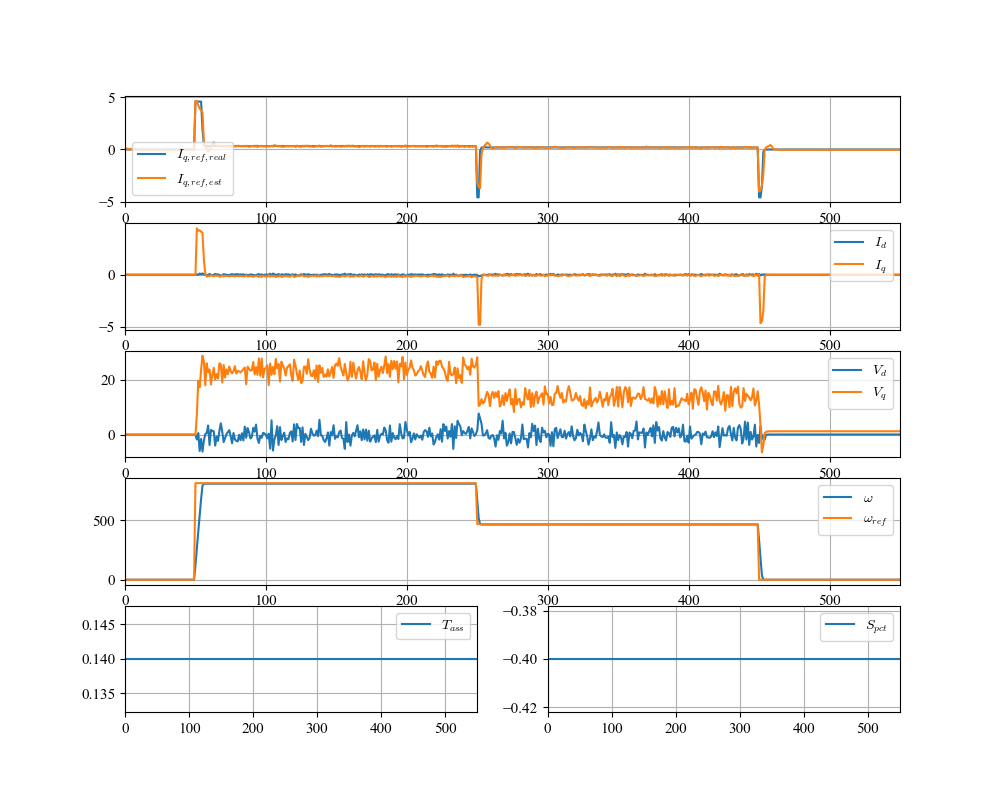

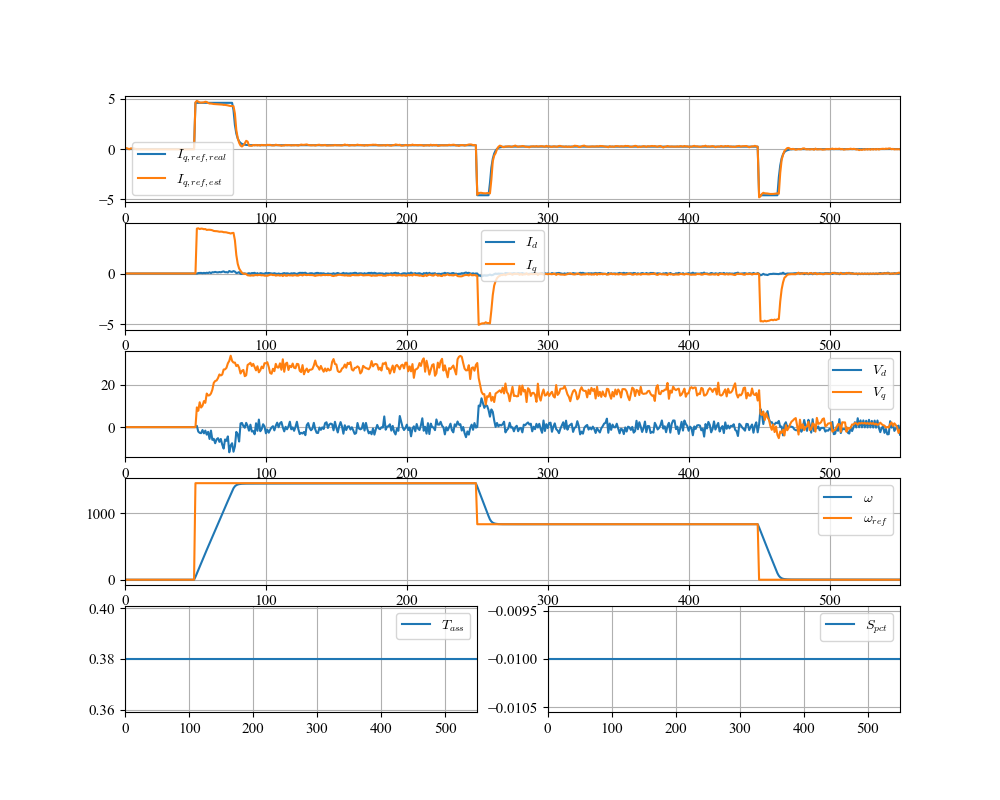

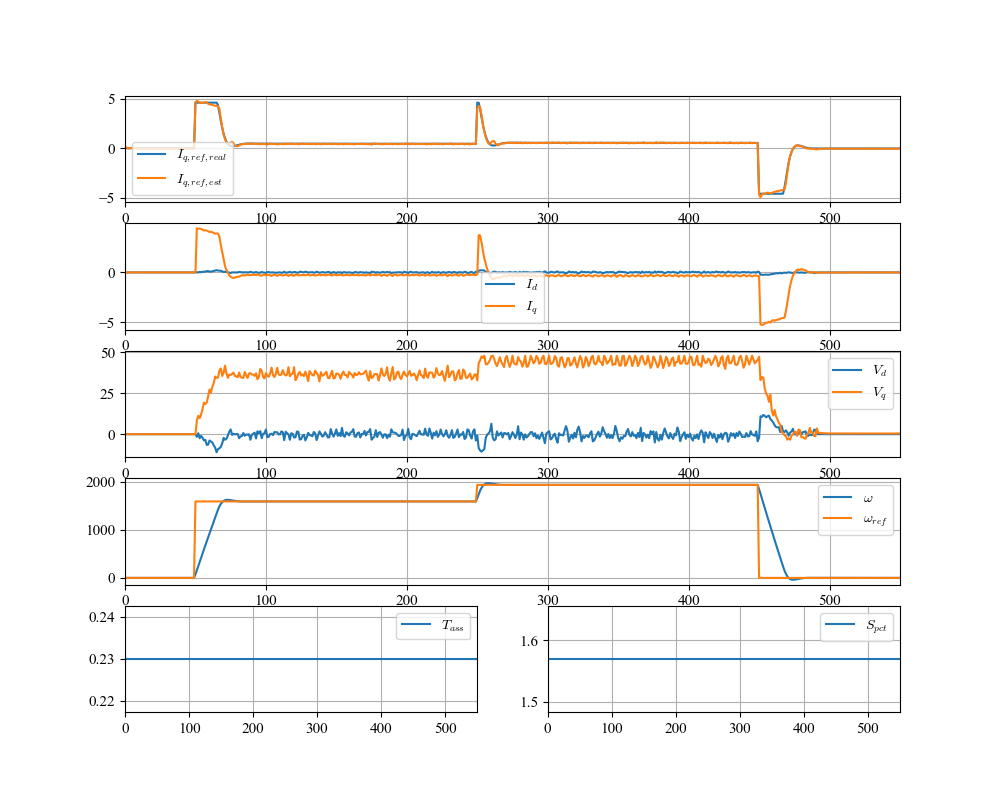

In [26]:
# show the first 10 experiments
for i in range(10):

    y_full_np = y_full_all.cpu().numpy()
    y_pred_np = y_pred_all.cpu().numpy()
    u_full_np = u_full_all.cpu().numpy()

    # print(y_full_np.shape)
    # print(u_full_np.shape)
    fig = plt.figure(figsize=(10,8))
    ax1 = fig.add_subplot(5,1,1)
    ax1.plot(y_full_np[i])
    ax1.plot(y_pred_np[i])
    ax1.legend([r'$I_{q,ref,real}$',r'$I_{q,ref,est}$'])
    ax2 = fig.add_subplot(5,1,2, sharex=ax1)
    ax2.plot(u_full_np[i,:,0])
    ax2.plot(u_full_np[i,:,1])
    ax2.legend([r'$I_{d}$',r'$I_{q}$'])
    ax3 = fig.add_subplot(5,1,3, sharex=ax1)
    ax3.plot(u_full_np[i,:,2])
    ax3.plot(u_full_np[i,:,3])
    ax3.legend([r'$V_{d}$',r'$V_{q}$'])
    ax4 = fig.add_subplot(5,1,4, sharex=ax1)
    ax4.plot(u_full_np[i,:,4])
    ax4.plot(u_full_np[i,:,5])
    ax4.legend([r'$\omega$',r'$\omega_{ref}$'])
    ax5 = fig.add_subplot(5,2,9)
    ax5.plot(u_full_np[i,:,6])
    ax5.legend([r'$T_{ass}$'])
    ax6 = fig.add_subplot(5,2,10)
    ax6.plot(u_full_np[i,:,7])
    ax6.legend([r'$S_{pct}$'])


    plt.show()
    

In [27]:
import copy
model_name_to_save = "test_controller.pt"
model_name_to_save2 = "test_controller2.pt"
torch.save(model, model_name_to_save)

model_name_to_save_onnx = "test_controller_onnx.onnx"
model_name_to_save_onnx_d = "test_controller_onnx_d.onnx"



model_copy = copy.deepcopy(model)
model_copy.to('cpu')
model_copy.eval()
# model.to('cpu')
# model_copy = copy.deepcopy(model)
# model_cpu = GPT(gptconf).to('cpu')

input_val_cpu = copy.deepcopy(input_val)
input_val_cpu.to('cpu')

mode_onnx = torch.onnx.export(model_copy, input_val_cpu[0:1,:,:], f=model_name_to_save_onnx)
mode_onnx_d = torch.onnx.export(model_copy, input_val_cpu[0:1,:,:], f=model_name_to_save_onnx_d, dynamo=True)

import onnx

onnx_model = onnx.load(model_name_to_save_onnx)
onnx.checker.check_model(onnx_model)
onnx_model = onnx.load(model_name_to_save_onnx_d)
onnx.checker.check_model(onnx_model)




# print(input_val_cpu.device)
# print(next(model_copy.parameters()).is_cuda)

# traced_model = torch.jit.trace(model_copy, input_val_cpu)
# torch.jit.save(traced_model, model_name_to_save2)
# model_jit = torch.jit.load(model_name_to_save2)

# print(model_jit(input_val_cpu[0:1,:,:])==model(input_val_cpu[0:1,:,:]))




c:\Users\39340\Documents\GitHub\in-context-bldc\speed_controller\transformer_zerostep.py:184: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  assert t <= self.config.block_size, f"Cannot forward sequence of length {t}, block size is only {self.config.block_size}"


[torch.onnx] Obtain model graph for `GPT([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `GPT([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


In [28]:
from transformer_zerostep_implied_flash import GPT_if
gptconf = GPTConfig(**model_args)
model_if = GPT_if(gptconf).to(device)
state_dict = exp_data["model"]
unwanted_prefix = '_orig_mod.'
for k,v in list(state_dict.items()):
    if k.startswith(unwanted_prefix):
        state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)
    if k.startswith('module.'):
        state_dict[k[7:]] = v
        state_dict.pop(k)

model_if.load_state_dict(state_dict)
model_name_to_save_if = "test_controller_if.pt"
traced_model_if = torch.jit.trace(model_if, input_val_cpu)
torch.jit.save(traced_model_if, model_name_to_save_if)


number of parameters: 0.03M


In [29]:

print(model_copy(input_val_cpu[0:1,:,:]))
print(model_if(input_val_cpu[0:1,:,:]))
model_name_to_save_onnx2 = "test_controller_onnx2.onnx"
mode_onnx = torch.onnx.export(model_if, input_val_cpu[0:1,:,:], f=model_name_to_save_onnx2, input_names=["input"], output_names=["output"] )

onnx_model2 = onnx.load(model_name_to_save_onnx2)
onnx.checker.check_model(onnx_model2)

for node in onnx_model2.graph.node:
    if node.op_type == "Trilu":
        print(f"Found Trilu operator in node: {node.name}")


tensor([[[-0.5566],
         [-0.5218],
         [-0.5215],
         [-0.5344],
         [-0.5225],
         [-0.5362],
         [-0.5359],
         [-0.5255],
         [-0.5367],
         [-0.5393]]], grad_fn=<ViewBackward0>)
tensor([[[-0.5566],
         [-0.5218],
         [-0.5215],
         [-0.5344],
         [-0.5225],
         [-0.5362],
         [-0.5359],
         [-0.5255],
         [-0.5367],
         [-0.5393]]], grad_fn=<ViewBackward0>)
Found Trilu operator in node: /h.0/attn/Trilu
Found Trilu operator in node: /h.1/attn/Trilu
Found Trilu operator in node: /h.2/attn/Trilu
Found Trilu operator in node: /h.3/attn/Trilu
Found Trilu operator in node: /h.4/attn/Trilu
Found Trilu operator in node: /h.5/attn/Trilu
Found Trilu operator in node: /h.6/attn/Trilu
Found Trilu operator in node: /h.7/attn/Trilu


In [60]:
input_val_new = copy.deepcopy(input_val_cpu[0:1,:,:]) *0
input_val_new = torch.zeros(1,10,8)
print(input_val_new)
print(model_if(input_val_new))

ref_value = model_if(input_val_new).flatten().detach().numpy()
print(ref_value)

tensor([[[0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0.]]])
tensor([[[-0.5587],
         [-0.5176],
         [-0.5232],
         [-0.5273],
         [-0.5134],
         [-0.5001],
         [-0.4963],
         [-0.5050],
         [-0.5050],
         [-0.5047]]], grad_fn=<ViewBackward0>)
[-0.5586742  -0.51758426 -0.52323973 -0.52731836 -0.5133732  -0.50009453
 -0.4963288  -0.504956   -0.5050378  -0.50469255]


In [61]:
import onnxruntime as rt

session = rt.InferenceSession(model_name_to_save_onnx2)
input_name = session.get_inputs()[0].name
input_shape = session.get_inputs()[0].shape
input_type = session.get_inputs()[0].type

print(f"Input name: {input_name}")
print(f"Input shape: {input_shape}")
print(f"Input type: {input_type}")

# Replace dynamic dimensions (None) with 1 for testing
input_shape_fixed = [dim if isinstance(dim, int) else 1 for dim in input_shape]

# Create a zero matrix with the fixed shape
input_data = np.zeros(input_shape_fixed, dtype=np.float32)


# Run inference
outputs = session.run(None, {input_name: input_data})

# Display the outputs
# print("Model output:")
# for output in outputs:

out = outputs[0].flatten()
print(out)


print(ref_value-out)

# input_data = torch.zeros(input_shape)
# outputs = session.run(None, {input_name: input_data})

# input = {"input": np.zeros((1,10,8))}

# output = session.run("output", input)


Input name: input
Input shape: [1, 10, 8]
Input type: tensor(float)
[-0.5586742  -0.51758426 -0.52323973 -0.5273183  -0.5133733  -0.50009453
 -0.49632886 -0.50495607 -0.5050379  -0.5046927 ]
[ 0.0000000e+00  0.0000000e+00  0.0000000e+00 -5.9604645e-08
  1.1920929e-07  0.0000000e+00  5.9604645e-08  5.9604645e-08
  1.1920929e-07  1.1920929e-07]


In [69]:
input_test = torch.zeros(1,10,8)
input_test[0,-1,5] = 1

ref = model_if(input_test).flatten().detach().numpy()

input_data = input_test.detach().numpy()
outputs = session.run(None, {input_name: input_data})
out = outputs[0].flatten()



print(input_val_cpu)
print(input_data)


print(ref)
print(out)

print(ref-out)





tensor([[[-1.7529e-03, -2.9001e-03,  8.7833e-02,  ...,  0.0000e+00,
           1.3000e-01, -7.8000e-01],
         [-1.7529e-03, -2.9001e-03,  8.7833e-02,  ...,  0.0000e+00,
           1.3000e-01, -7.8000e-01],
         [-1.7529e-03, -2.9001e-03,  8.7833e-02,  ...,  0.0000e+00,
           1.3000e-01, -7.8000e-01],
         ...,
         [-1.7529e-03, -2.9001e-03,  8.7833e-02,  ...,  0.0000e+00,
           1.3000e-01, -7.8000e-01],
         [-1.7529e-03, -2.9001e-03,  8.7833e-02,  ...,  0.0000e+00,
           1.3000e-01, -7.8000e-01],
         [-1.7529e-03, -2.9001e-03,  8.7833e-02,  ...,  0.0000e+00,
           1.3000e-01, -7.8000e-01]],

        [[-1.1468e-03, -1.7791e-03,  5.5258e-02,  ...,  0.0000e+00,
           3.3000e-01, -1.5300e+00],
         [-1.1468e-03, -1.7791e-03,  5.5258e-02,  ...,  0.0000e+00,
           3.3000e-01, -1.5300e+00],
         [-1.1468e-03, -1.7781e-03,  5.5258e-02,  ...,  0.0000e+00,
           3.3000e-01, -1.5300e+00],
         ...,
         [-1.1468e-03, -1

In [30]:
# from transformer_zerostep_manual_flash import GPT_mf
# gptconf = GPTConfig(**model_args)
# model_mf = GPT_mf(gptconf).to(device)
# state_dict = exp_data["model"]
# unwanted_prefix = '_orig_mod.'
# for k,v in list(state_dict.items()):
#     if k.startswith(unwanted_prefix):
#         state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)
#     if k.startswith('module.'):
#         state_dict[k[7:]] = v
#         state_dict.pop(k)

# print(state_dict.keys())

# model_mf.load_state_dict(state_dict)
# # model_name_to_save_if = "test_controller_if.pt"
# # traced_model_if = torch.jit.trace(model_if, input_val_cpu)
# # torch.jit.save(traced_model_if, model_name_to_save_if)

# print(model_copy(input_val_cpu[0:1,:,:]))
# print(model_mf(input_val_cpu[0:1,:,:]))


# model_name_to_save_onnx3 = "test_controller_onnx3.onnx"
# mode_onnx = torch.onnx.export(model_mf, input_val_cpu[0:1,:,:], f=model_name_to_save_onnx3, input_names=["input"], output_names=["output"] )

# onnx_model3 = onnx.load(model_name_to_save_onnx3)
# onnx.checker.check_model(onnx_model3)

# for node in onnx_model3.graph.node:
#     if node.op_type == "Trilu":
#         print(f"Found Trilu operator in node: {node.name}")